This notebooks perform a representation-level analysis, part of the report, by computing margins between correct and incorrect centroids using hidden states. The evolution of these margins across sparsity levels (0.0, 0.25, 0.60) is analyzed to study how pruning affects representation alignment, noise, and overall signal quality.

The hidden states can be accessed from the specified directory in the cells. Before running the notebook, make sure to add the shared Google Drive folder to your “My Drive” using the provided link (https://drive.google.com/drive/folders/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K?usp=sharing). 

To do this:
1. Open the shared folder link.
2. Click on “Add shortcut to Drive”.
3. Select “My Drive” as the destination.

After that, the folder will be accessible in Colab through the mounted Google Drive (e.g., /content/drive/MyDrive/...), allowing the hidden states to be loaded directly.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

# CHANGE this to your repo folder
%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Mounted at /content/drive
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build		    experiments  pyproject.toml  src	     test.sh
build_and_test.sh   LICENSE	 README.md	 SUPPORT.md
CODE_OF_CONDUCT.md  pipelines	 SECURITY.md	 tests


In [2]:
import os
import ast
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

In [51]:
# =========================
# CONFIG
# =========================
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_Qwen2-1.5B-Instruct_pca")
ANALYSIS_DIR = os.path.join(BASE_RESULTS_DIR, "analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs")
METRICS_DIR = os.path.join(ANALYSIS_DIR, "squad2_hasans_eval_all_layers_mlp_output")

MODEL_NAME_TAG = "Qwen-Qwen2-1p5B-Instruct"
CALIBRATION_DATASET = "coqa"
EVAL_DATASET_NAME = "squad2"

# Use the sparsities relevant to the spike story
SPARSITIES = [0.0, 0.25, 0.6]

# Start with one layer
LAYER_IDX = 26
ACTIVATION_KIND = "mlp_output"

# correctness based on exact match first
USE_EXACT_LABEL = False

# transition groups to inspect
FOCUS_GROUPS = ["0->1->0", "1->1->1", "0->0->0", "0->1->1", "1->1->0", "1->0->0", "1->0->1", "0->0->1"]

print("METRICS_DIR:", METRICS_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("SPARSITIES:", SPARSITIES)
print("LAYER_IDX:", LAYER_IDX)

METRICS_DIR: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output
MODEL_DIR: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca
SPARSITIES: [0.0, 0.25, 0.6]
LAYER_IDX: 26


In [52]:
def get_metrics_path(sparsity: float) -> str:
    fname = (
        f"{MODEL_NAME_TAG}_{CALIBRATION_DATASET}_on_{EVAL_DATASET_NAME}_hasans_s{sparsity:.2f}"
        .replace(".", "p")
        + "_sample_metrics.csv"
    )
    return os.path.join(METRICS_DIR, fname)


def get_hidden_state_path(sparsity: float, layer_idx: int) -> str:
    subdir = os.path.join(
        MODEL_DIR,
        f"Qwen-Qwen2-1p5B-Instruct_{CALIBRATION_DATASET}_s{sparsity:.2f}".replace(".", "p"),
        "hidden_states"
    )
    fname = f"layer_{layer_idx}_{ACTIVATION_KIND}_hasans_eval_first_token_hs.pt"
    return os.path.join(subdir, fname)


def load_metrics_df(sparsity: float) -> pd.DataFrame:
    path = get_metrics_path(sparsity)
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    return df


def load_hidden_states_tensor(sparsity: float, layer_idx: int) -> torch.Tensor:
    path = get_hidden_state_path(sparsity, layer_idx)
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    H = torch.load(path, map_location="cpu")
    if not isinstance(H, torch.Tensor):
        H = torch.tensor(H)
    return H.float()


def l2_normalize_rows(X: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return X / X.norm(dim=1, keepdim=True).clamp_min(eps)


def cosine_to_vector(X: torch.Tensor, v: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    Xn = l2_normalize_rows(X, eps=eps)
    vn = v / v.norm().clamp_min(eps)
    return Xn @ vn


def parse_gold_answers(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
            return [str(parsed)]
        except Exception:
            return [x]
    return [str(x)]

In [53]:
def build_signal_noise_scores_for_sparsity(
    sparsity: float,
    layer_idx: int,
    use_exact_label: bool = True
) -> pd.DataFrame:
    df = load_metrics_df(sparsity).copy().sort_values("sample_id").reset_index(drop=True)
    H = load_hidden_states_tensor(sparsity, layer_idx)

    if len(df) != H.shape[0]:
        raise ValueError(
            f"Row mismatch at sparsity={sparsity}: df={len(df)} vs H={H.shape[0]}"
        )

    if use_exact_label:
        y = (df["exact"] == 100).astype(int).values
        label_name = "exact_correct"
    else:
        y = (df["f1"] >= 50).astype(int).values
        label_name = "f1_correct"

    y_t = torch.tensor(y, dtype=torch.bool)

    num_correct = int(y_t.sum().item())
    num_incorrect = int((~y_t).sum().item())

    if num_correct == 0 or num_incorrect == 0:
        raise ValueError(
            f"sparsity={sparsity}: need both correct and incorrect samples, "
            f"got correct={num_correct}, incorrect={num_incorrect}"
        )

    H_correct = H[y_t]
    H_incorrect = H[~y_t]

    mu_correct = H_correct.mean(dim=0)
    mu_incorrect = H_incorrect.mean(dim=0)

    sim_to_correct = cosine_to_vector(H, mu_correct).numpy()
    sim_to_incorrect = cosine_to_vector(H, mu_incorrect).numpy()
    margin = sim_to_correct - sim_to_incorrect

    out = df.copy()
    out["sparsity"] = sparsity
    out[label_name] = y.astype(int)
    out["sim_to_correct"] = sim_to_correct
    out["sim_to_incorrect"] = sim_to_incorrect
    out["margin"] = margin

    # compactness / spread diagnostics
    correct_self_sim = cosine_to_vector(H_correct, mu_correct).numpy()
    incorrect_self_sim = cosine_to_vector(H_incorrect, mu_incorrect).numpy()

    diagnostics = {
        "sparsity": sparsity,
        "layer": layer_idx,
        "label_name": label_name,
        "num_samples": len(df),
        "num_correct": num_correct,
        "num_incorrect": num_incorrect,
        "mean_margin_all": float(np.mean(margin)),
        "mean_sim_to_correct_all": float(np.mean(sim_to_correct)),
        "mean_sim_to_incorrect_all": float(np.mean(sim_to_incorrect)),
        "mean_correct_to_correct_proto": float(np.mean(correct_self_sim)),
        "mean_incorrect_to_incorrect_proto": float(np.mean(incorrect_self_sim)),
        "proto_cosine": float(
            torch.nn.functional.cosine_similarity(
                mu_correct.unsqueeze(0), mu_incorrect.unsqueeze(0)
            ).item()
        ),
        "proto_l2_dist": float(torch.norm(mu_correct - mu_incorrect).item()),
    }

    return out, diagnostics

In [54]:
all_scored = []
diagnostics_rows = []

for s in SPARSITIES:
    scored_df, diag = build_signal_noise_scores_for_sparsity(
        sparsity=s,
        layer_idx=LAYER_IDX,
        use_exact_label=USE_EXACT_LABEL
    )
    all_scored.append(scored_df)
    diagnostics_rows.append(diag)

diagnostics_df = pd.DataFrame(diagnostics_rows)
display(diagnostics_df)

scored_all = pd.concat(all_scored, axis=0, ignore_index=True)
print("scored_all shape:", scored_all.shape)
display(scored_all.head())

,sparsity,layer,label_name,num_samples,num_correct,num_incorrect,mean_margin_all,mean_sim_to_correct_all,mean_sim_to_incorrect_all,mean_correct_to_correct_proto,mean_incorrect_to_incorrect_proto,proto_cosine,proto_l2_dist
0,0.00,26,f1_correct,5928,1844,4084,-0.003428,0.463487,0.466915,0.457175,0.472077,0.991929,2.680417
1,0.25,26,f1_correct,5928,3337,2591,-0.001134,0.587101,0.588235,0.573287,0.611519,0.991624,3.329946
2,0.60,26,f1_correct,5928,19,5909,-0.003791,0.956059,0.959850,0.937692,0.959934,0.996032,4.843624


scored_all shape: (17784, 17)


,sample_id,row_idx,title,question,context,prompt,prediction_raw,prediction,gold_answers,no_answer_probability,f1,exact,sparsity,f1_correct,sim_to_correct,sim_to_incorrect,margin
0,56ddde6b9a695914005b9628,0,Normans,In what country is Normandy located?,The Normans (Norman: Nourmands; French: Norman...,Title: Normans\n\nBackground: The Normans (Nor...,Normandy is located in France. It is a region...,Normandy is located in France. It is a region...,"[""France"", ""France"", ""France"", ""France""]",0.001160,9.090909,0.0,0.0,0,0.059366,0.032205,0.027160
1,56ddde6b9a695914005b9629,1,Normans,When were the Normans in Normandy?,The Normans (Norman: Nourmands; French: Norman...,Title: Normans\n\nBackground: The Normans (Nor...,The Normans were in Normandy from the 10th ce...,The Normans were in Normandy from the 10th ce...,"[""10th and 11th centuries"", ""in the 10th and 1...",0.006400,19.047619,0.0,0.0,0,0.434424,0.452037,-0.017613
2,56ddde6b9a695914005b962a,2,Normans,From which countries did the Norse originate?,The Normans (Norman: Nourmands; French: Norman...,Title: Normans\n\nBackground: The Normans (Nor...,The Norse (also known as Normans) originated ...,The Norse (also known as Normans) originated ...,"[""Denmark, Iceland and Norway"", ""Denmark, Icel...",0.001160,28.571429,0.0,0.0,0,0.572438,0.610564,-0.038126
3,56ddde6b9a695914005b962b,3,Normans,Who was the Norse leader?,The Normans (Norman: Nourmands; French: Norman...,Title: Normans\n\nBackground: The Normans (Nor...,Rollo\n\nIs the question answered in a satisf...,Rollo,"[""Rollo"", ""Rollo"", ""Rollo"", ""Rollo""]",0.000142,100.000000,100.0,0.0,1,0.099819,0.080821,0.018997
4,56ddde6b9a695914005b962c,4,Normans,What century did the Normans first gain their ...,The Normans (Norman: Nourmands; French: Norman...,Title: Normans\n\nBackground: The Normans (Nor...,The Normans first gained their separate ident...,The Normans first gained their separate ident...,"[""10th century"", ""the first half of the 10th c...",0.002625,35.714286,0.0,0.0,0,0.635750,0.674018,-0.038268


In [55]:
# =========================
# LOAD TRANSITION FILE
# =========================
TRANSITION_PATH = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output/transition_analysis_s0p00_s0p25_s0p60_enriched.csv"

transition_df = pd.read_csv(TRANSITION_PATH)
transition_df = transition_df.sort_values("sample_id").reset_index(drop=True)

print("Transition df shape:", transition_df.shape)
display(transition_df.head())




Transition df shape: (5928, 44)


,sample_id,question,context,gold_answers,gold_answers_parsed,prediction_s0.0,f1_s0.0,exact_s0.0,prediction_s0.25,f1_s0.25,...,pred_len_chars_s0.6,pred_len_words_s0.6,gold_overlap_precision_s0.6,is_substring_context_s0.6,is_empty_pred_s0.6,is_very_short_pred_s0.6,pred_jaccard_s0.0_to_s0.25,pred_exact_match_s0.0_to_s0.25,pred_jaccard_s0.25_to_s0.6,pred_exact_match_s0.25_to_s0.6
0,56ddde6b9a695914005b9628,In what country is Normandy located?,The Normans (Norman: Nourmands; French: Norman...,"[""France"", ""France"", ""France"", ""France""]","['France', 'France', 'France', 'France']",Normandy is located in France. It is a region...,9.090909,0.0,France.,100.000000,...,32,6,0.000000,0,0,0,0.052632,0,0.000000,0
1,56ddde6b9a695914005b9629,When were the Normans in Normandy?,The Normans (Norman: Nourmands; French: Norman...,"[""10th and 11th centuries"", ""in the 10th and 1...","['10th and 11th centuries', 'in the 10th and 1...",The Normans were in Normandy from the 10th ce...,19.047619,0.0,The Normans were in Normandy in the 10th and ...,71.428571,...,53,11,0.272727,0,0,0,0.428571,0,0.200000,0
2,56ddde6b9a695914005b962a,From which countries did the Norse originate?,The Normans (Norman: Nourmands; French: Norman...,"[""Denmark, Iceland and Norway"", ""Denmark, Icel...","['Denmark, Iceland and Norway', 'Denmark, Icel...",The Norse (also known as Normans) originated ...,28.571429,0.0,Norse.,0.000000,...,135,27,0.000000,0,0,0,0.043478,0,0.333333,0
3,56ddde6b9a695914005b962b,Who was the Norse leader?,The Normans (Norman: Nourmands; French: Norman...,"[""Rollo"", ""Rollo"", ""Rollo"", ""Rollo""]","['Rollo', 'Rollo', 'Rollo', 'Rollo']",Rollo,100.000000,100.0,Rollo.,100.000000,...,26,5,0.000000,0,0,0,1.000000,0,0.000000,0
4,56ddde6b9a695914005b962c,What century did the Normans first gain their ...,The Normans (Norman: Nourmands; French: Norman...,"[""10th century"", ""the first half of the 10th c...","['10th century', 'the first half of the 10th c...",The Normans first gained their separate ident...,35.714286,0.0,The 10th century.,100.000000,...,65,10,0.300000,0,0,0,0.136364,0,0.181818,0


In [56]:
# =========================
# MERGE WITH SCORED DATA
# =========================
scored_all = scored_all.merge(
    transition_df[["sample_id", "transition_exact"]],
    on="sample_id",
    how="left"
)

print("After merge:")
print(scored_all["transition_exact"].value_counts().head(10))

After merge:
transition_exact
0->0->0    10740
0->1->0     3996
1->1->0     1983
1->0->0     1065
Name: count, dtype: int64


In [57]:
summary_by_group = (
    scored_all
    .groupby(["sparsity", "transition_exact"])
    .agg(
        count=("sample_id", "count"),
        mean_margin=("margin", "mean"),
        median_margin=("margin", "median"),
        std_margin=("margin", "std"),
        mean_sim_to_correct=("sim_to_correct", "mean"),
        mean_sim_to_incorrect=("sim_to_incorrect", "mean"),
        mean_exact=("exact", "mean"),
        mean_f1=("f1", "mean"),
    )
    .reset_index()
    .sort_values(["transition_exact", "sparsity"])
)

display(summary_by_group.head(20))

,sparsity,transition_exact,count,mean_margin,median_margin,std_margin,mean_sim_to_correct,mean_sim_to_incorrect,mean_exact,mean_f1
0,0.00,0->0->0,3580,-0.006259,-0.007914,0.028588,0.473817,0.480076,0.0,27.099896
4,0.25,0->0->0,3580,-0.005039,-0.012178,0.038115,0.602314,0.607352,0.0,33.379459
8,0.60,0->0->0,3580,-0.003816,-0.004225,0.003582,0.955630,0.959446,0.0,2.845462
1,0.00,0->1->0,1332,-0.003014,-0.000863,0.028780,0.452950,0.455964,0.0,24.584342
5,0.25,0->1->0,1332,0.006447,0.001765,0.040296,0.560205,0.553758,100.0,100.000000
9,0.60,0->1->0,1332,-0.003934,-0.004443,0.003791,0.956646,0.960580,0.0,2.715796
2,0.00,1->0->0,355,0.003118,0.008657,0.028951,0.452058,0.448940,100.0,100.000000
6,0.25,1->0->0,355,-0.006829,-0.015105,0.038674,0.603003,0.609831,0.0,29.129990
10,0.60,1->0->0,355,-0.003476,-0.004017,0.005043,0.956254,0.959729,0.0,1.854647
3,0.00,1->1->0,661,0.007553,0.013639,0.030675,0.434908,0.427355,100.0,100.000000


In [58]:
focus_summary = summary_by_group[summary_by_group["transition_exact"].isin(FOCUS_GROUPS)].copy()

display(
    focus_summary.sort_values(["transition_exact", "sparsity"])
)

,sparsity,transition_exact,count,mean_margin,median_margin,std_margin,mean_sim_to_correct,mean_sim_to_incorrect,mean_exact,mean_f1
0,0.00,0->0->0,3580,-0.006259,-0.007914,0.028588,0.473817,0.480076,0.0,27.099896
4,0.25,0->0->0,3580,-0.005039,-0.012178,0.038115,0.602314,0.607352,0.0,33.379459
8,0.60,0->0->0,3580,-0.003816,-0.004225,0.003582,0.955630,0.959446,0.0,2.845462
1,0.00,0->1->0,1332,-0.003014,-0.000863,0.028780,0.452950,0.455964,0.0,24.584342
5,0.25,0->1->0,1332,0.006447,0.001765,0.040296,0.560205,0.553758,100.0,100.000000
9,0.60,0->1->0,1332,-0.003934,-0.004443,0.003791,0.956646,0.960580,0.0,2.715796
2,0.00,1->0->0,355,0.003118,0.008657,0.028951,0.452058,0.448940,100.0,100.000000
6,0.25,1->0->0,355,-0.006829,-0.015105,0.038674,0.603003,0.609831,0.0,29.129990
10,0.60,1->0->0,355,-0.003476,-0.004017,0.005043,0.956254,0.959729,0.0,1.854647
3,0.00,1->1->0,661,0.007553,0.013639,0.030675,0.434908,0.427355,100.0,100.000000


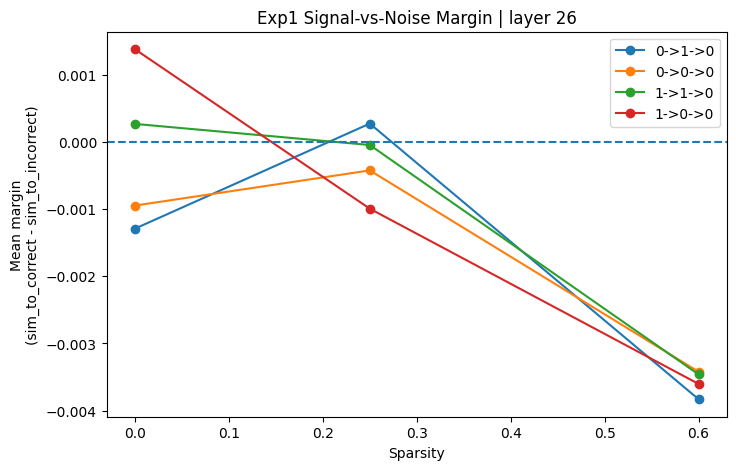

In [21]:
plot_df = focus_summary.copy()

plt.figure(figsize=(8, 5))

for group in FOCUS_GROUPS:
    cur = plot_df[plot_df["transition_exact"] == group].sort_values("sparsity")
    if len(cur) == 0:
        continue
    plt.plot(cur["sparsity"], cur["mean_margin"], marker="o", label=group)

plt.axhline(0.0, linestyle="--")
plt.xlabel("Sparsity")
plt.ylabel("Mean margin\n(sim_to_correct - sim_to_incorrect)")
plt.title(f"Exp1 Signal-vs-Noise Margin | layer {LAYER_IDX}")
plt.legend()
plt.show()

,sparsity,count,mean_margin,median_margin,std_margin
0,0.00,5928,-0.000749,-0.002138,0.008855
1,0.25,5928,-0.000259,-0.000316,0.005428
2,0.60,5928,-0.003528,-0.001758,0.010168


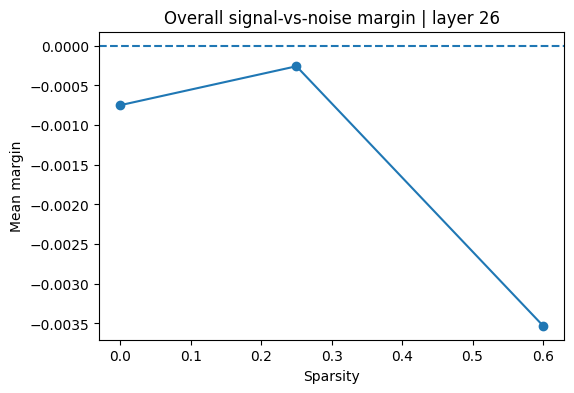

In [ ]:
overall_margin = (
    scored_all
    .groupby("sparsity")
    .agg(
        count=("sample_id", "count"),
        mean_margin=("margin", "mean"),
        median_margin=("margin", "median"),
        std_margin=("margin", "std"),
    )
    .reset_index()
)

display(overall_margin)

plt.figure(figsize=(6, 4))
plt.plot(overall_margin["sparsity"], overall_margin["mean_margin"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Sparsity")
plt.ylabel("Mean margin")
plt.title(f"Overall signal-vs-noise margin | layer {LAYER_IDX}")
plt.show()

'''
The mean margin increases (becomes less negative) at moderate sparsity, indicating that representations shift toward the correct-answer subspace.
At higher sparsity, the margin sharply decreases, suggesting a collapse of discriminative structure.
On average, representations are still slightly closer to incorrect than correct
'''

Target group size: 3996


,count,mean,std,min,25%,50%,75%,max
sparsity,,,,,,,,
0.00,1332.0,-0.001291,0.008599,-0.021524,-0.008059,-0.002678,0.004703,0.023712
0.25,1332.0,0.000274,0.005499,-0.016766,-0.003176,0.000089,0.004223,0.040468
0.60,1332.0,-0.003830,0.009913,-0.038908,-0.011002,-0.002574,0.003869,0.018090


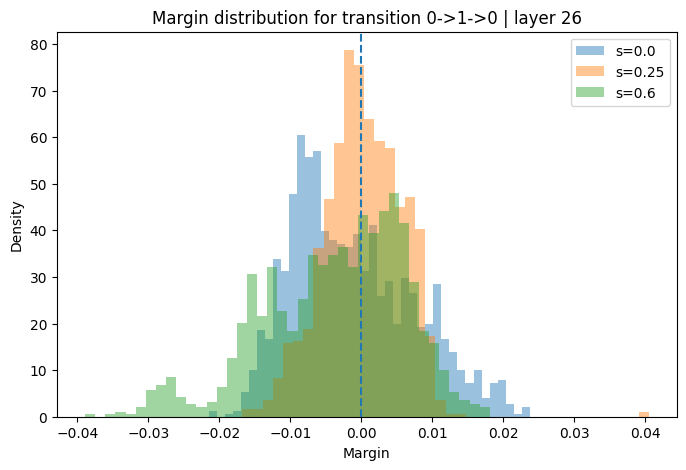

In [ ]:
target_group = "0->1->0"
sub = scored_all[scored_all["transition_exact"] == target_group].copy()

print("Target group size:", len(sub))
display(
    sub.groupby("sparsity")["margin"].describe()
)

plt.figure(figsize=(8, 5))
for s in SPARSITIES:
    cur = sub[sub["sparsity"] == s]["margin"].values
    if len(cur) == 0:
        continue
    plt.hist(cur, bins=40, alpha=0.45, label=f"s={s}", density=True)

plt.axvline(0.0, linestyle="--")
plt.xlabel("Margin")
plt.ylabel("Density")
plt.title(f"Margin distribution for transition {target_group} | layer {LAYER_IDX}")
plt.legend()
plt.show()

In [46]:
OUT_DIR = os.path.join(ANALYSIS_DIR, f"exp1_signal_vs_noise_layer_{LAYER_IDX}")
os.makedirs(OUT_DIR, exist_ok=True)

scored_all_path = os.path.join(OUT_DIR, "scored_all_samples.csv")
diag_path = os.path.join(OUT_DIR, "diagnostics.csv")
summary_path = os.path.join(OUT_DIR, "summary_by_transition.csv")
focus_path = os.path.join(OUT_DIR, "focus_summary.csv")

scored_all.to_csv(scored_all_path, index=False)
diagnostics_df.to_csv(diag_path, index=False)
summary_by_group.to_csv(summary_path, index=False)
focus_summary.to_csv(focus_path, index=False)

print("Saved:")
print(scored_all_path)
print(diag_path)
print(summary_path)
print(focus_path)

Saved:
/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/exp1_signal_vs_noise_layer_26/scored_all_samples.csv
/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/exp1_signal_vs_noise_layer_26/diagnostics.csv
/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/exp1_signal_vs_noise_layer_26/summary_by_transition.csv
/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/exp1_signal_vs_noise_layer_26/focus_summary.csv


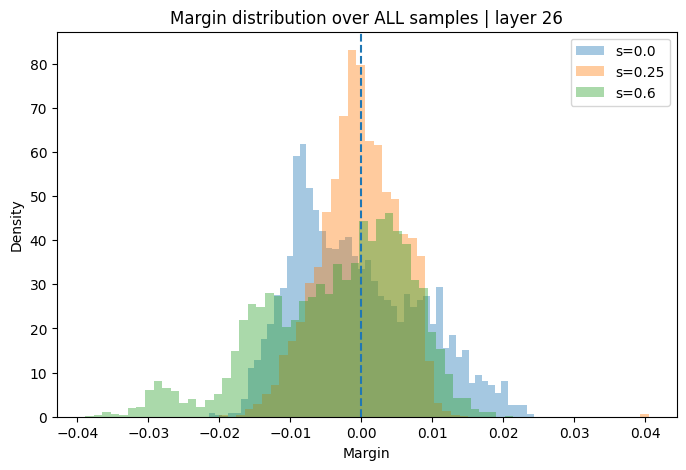

In [ ]:
plt.figure(figsize=(8, 5))

for s in SPARSITIES:
    cur = scored_all[scored_all["sparsity"] == s]["margin"].values
    if len(cur) == 0:
        continue
    plt.hist(cur, bins=50, alpha=0.40, label=f"s={s}", density=True)

plt.axvline(0.0, linestyle="--")
plt.xlabel("Margin")
plt.ylabel("Density")
plt.title(f"Margin distribution over ALL samples | layer {LAYER_IDX}")
plt.legend()
plt.show()

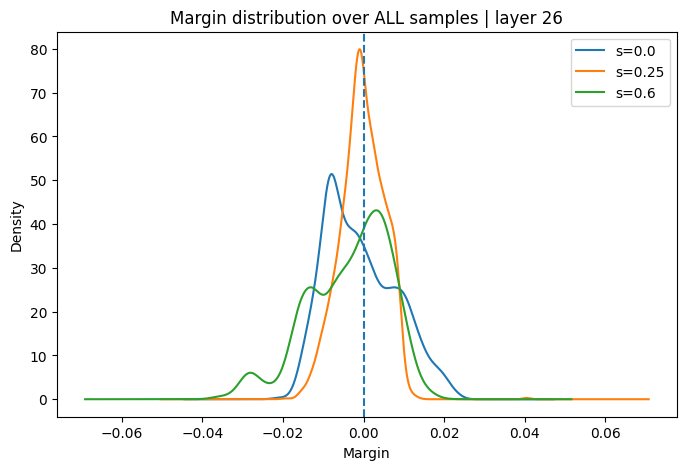

In [ ]:
plt.figure(figsize=(8, 5))

for s in SPARSITIES:
    cur = scored_all[scored_all["sparsity"] == s]["margin"]
    cur.plot(kind="kde", label=f"s={s}")

plt.axvline(0.0, linestyle="--")
plt.xlabel("Margin")
plt.ylabel("Density")
plt.title(f"Margin distribution over ALL samples | layer {LAYER_IDX}")
plt.legend()
plt.show()
'''
Moderate pruning reduces variance and sharpens the distribution of hidden representations, while slightly shifting them toward the correct-answer region. In contrast,
aggressive pruning increases variance and shifts representations toward incorrect regions, indicating a collapse of meaningful structure.


The margin distributions show that moderate pruning leads to a more concentrated and slightly right-shifted representation space, indicating reduced noise and improved
alignment with correct answers, whereas excessive pruning results in a broader and left-shifted distribution, reflecting degraded and less discriminative representations.
'''

In [49]:
import pandas as pd

# Path
csv_path = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact.csv"

# Load
df = pd.read_csv(csv_path)

print("Original columns:")
print(df.columns.tolist())

# ---- Identify columns related to "empty rate" ----
# (adapt this filter if needed depending on exact naming)
empty_cols = [col for col in df.columns if "empty" in col.lower()]

print("\nColumns to remove (empty-related):")
print(empty_cols)

# ---- Drop them ----
df_clean = df.drop(columns=empty_cols)

print("\nRemaining columns:")
print(df_clean.columns.tolist())

# ---- Optional: preview ----
display(df_clean.head())

# ---- Optional: save cleaned version ----
output_path = csv_path.replace(".csv", "_no_empty.csv")
df_clean.to_csv(output_path, index=False)

print(f"\nSaved cleaned CSV to: {output_path}")

Original columns:
['transition_f1', 'count', 'f1_s0.0_mean', 'f1_s0.25_mean', 'f1_s0.6_mean', 'exact_s0.0_mean', 'exact_s0.25_mean', 'exact_s0.6_mean', 'pred_len_words_s0.0_mean', 'pred_len_words_s0.25_mean', 'pred_len_words_s0.6_mean', 'gold_overlap_precision_s0.0_mean', 'gold_overlap_precision_s0.25_mean', 'gold_overlap_precision_s0.6_mean', 'substring_rate_pct_s0.0', 'substring_rate_pct_s0.25', 'substring_rate_pct_s0.6', 'pred_jaccard_s0.0_to_s0.25_mean', 'pred_jaccard_s0.25_to_s0.6_mean', 'pred_exact_match_rate_pct_s0.0_to_s0.25', 'pred_exact_match_rate_pct_s0.25_to_s0.6', 'empty_rate_pct_s0.0', 'empty_rate_pct_s0.25', 'empty_rate_pct_s0.6']

Columns to remove (empty-related):
['empty_rate_pct_s0.0', 'empty_rate_pct_s0.25', 'empty_rate_pct_s0.6']

Remaining columns:
['transition_f1', 'count', 'f1_s0.0_mean', 'f1_s0.25_mean', 'f1_s0.6_mean', 'exact_s0.0_mean', 'exact_s0.25_mean', 'exact_s0.6_mean', 'pred_len_words_s0.0_mean', 'pred_len_words_s0.25_mean', 'pred_len_words_s0.6_mean', 

,transition_f1,count,f1_s0.0_mean,f1_s0.25_mean,f1_s0.6_mean,exact_s0.0_mean,exact_s0.25_mean,exact_s0.6_mean,pred_len_words_s0.0_mean,pred_len_words_s0.25_mean,...,gold_overlap_precision_s0.0_mean,gold_overlap_precision_s0.25_mean,gold_overlap_precision_s0.6_mean,substring_rate_pct_s0.0,substring_rate_pct_s0.25,substring_rate_pct_s0.6,pred_jaccard_s0.0_to_s0.25_mean,pred_jaccard_s0.25_to_s0.6_mean,pred_exact_match_rate_pct_s0.0_to_s0.25,pred_exact_match_rate_pct_s0.25_to_s0.6
0,0->0->0,2106,16.712977,15.538407,2.031343,0.000000,0.000000,0.0,21.817664,11.003324,...,0.102421,0.112080,0.025098,19.800570,11.253561,0.189934,0.345769,0.138585,4.938272,0.0
1,0->1->0,1965,20.635533,85.644285,2.567740,0.000000,58.727735,0.0,22.347583,4.304835,...,0.120206,0.789282,0.027770,13.689567,18.778626,0.152672,0.177125,0.082799,0.000000,0.0
2,1->1->0,1359,84.823568,87.796894,2.715922,56.659308,61.295070,0.0,7.710081,5.640177,...,0.781722,0.831819,0.036168,58.646063,18.469463,0.073584,0.759453,0.071001,17.586461,0.0
3,1->0->0,479,82.542025,15.759936,3.115182,50.939457,0.000000,0.0,8.392484,8.891441,...,0.749262,0.148730,0.039973,54.697286,13.778706,0.000000,0.144190,0.120287,0.000000,0.0
4,0->1->1,8,26.259926,77.391098,59.346591,0.000000,25.000000,0.0,21.875000,9.000000,...,0.196587,0.679167,0.525818,0.000000,25.000000,0.000000,0.299254,0.452056,0.000000,0.0



Saved cleaned CSV to: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact_no_empty.csv


In [ ]:
import pandas as pd

# Load
csv_path = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact.csv"
df = pd.read_csv(csv_path)

# Total samples
total_count = df["count"].sum()

def weighted_avg(col):
    return (df[col] * df["count"]).sum() / total_count

# ---- Compute global metrics ----
results = {
    # Prediction length
    "pred_len_s0.0": weighted_avg("pred_len_words_s0.0_mean"),
    "pred_len_s0.25": weighted_avg("pred_len_words_s0.25_mean"),
    "pred_len_s0.6": weighted_avg("pred_len_words_s0.6_mean"),

    # Overlap
    "overlap_s0.0": weighted_avg("gold_overlap_precision_s0.0_mean"),
    "overlap_s0.25": weighted_avg("gold_overlap_precision_s0.25_mean"),
    "overlap_s0.6": weighted_avg("gold_overlap_precision_s0.6_mean"),

    # Extractiveness
    "extract_s0.0": weighted_avg("substring_rate_pct_s0.0"),
    "extract_s0.25": weighted_avg("substring_rate_pct_s0.25"),
    "extract_s0.6": weighted_avg("substring_rate_pct_s0.6"),

}

# Convert to dataframe for nicer display
df_global = pd.DataFrame(results, index=["weighted_avg"]).T

display(df_global)

# ---- Optional: save cleaned version ----
output_path = csv_path.replace(".csv", "_avg_tran_combined.csv")
df_global.to_csv(output_path, index=True)

print(f"\nSaved cleaned CSV to: {output_path}")

,weighted_avg
pred_len_s0.0,17.654858
pred_len_s0.25,7.375843
pred_len_s0.6,22.474022
overlap_s0.0,0.317127
overlap_s0.25,0.506047
overlap_s0.6,0.031060
extract_s0.0,29.487179
extract_s0.25,15.620783
extract_s0.6,0.134953



Saved cleaned CSV to: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact_avg_tran_combined.csv


In [60]:
import pandas as pd

# Load
csv_path = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact.csv"
df = pd.read_csv(csv_path)

# Total samples
total_count = df["count"].sum()

def weighted_avg(col):
    return (df[col] * df["count"]).sum() / total_count

# ---- Compute global metrics ----
results = {
    # Prediction length
    "pred_len_s0.0": weighted_avg("pred_len_words_s0.0_mean"),
    "pred_len_s0.25": weighted_avg("pred_len_words_s0.25_mean"),
    "pred_len_s0.6": weighted_avg("pred_len_words_s0.6_mean"),

    # Overlap
    "overlap_s0.0": weighted_avg("gold_overlap_precision_s0.0_mean"),
    "overlap_s0.25": weighted_avg("gold_overlap_precision_s0.25_mean"),
    "overlap_s0.6": weighted_avg("gold_overlap_precision_s0.6_mean"),

    # Extractiveness
    "extract_s0.0": weighted_avg("substring_rate_pct_s0.0"),
    "extract_s0.25": weighted_avg("substring_rate_pct_s0.25"),
    "extract_s0.6": weighted_avg("substring_rate_pct_s0.6"),

}

# Convert to dataframe for nicer display
df_global = pd.DataFrame(results, index=["weighted_avg"]).T

display(df_global)

# ---- Optional: save cleaned version ----
output_path = csv_path.replace(".csv", "_avg_tran_combined.csv")
df_global.to_csv(output_path, index=True)

print(f"\nSaved cleaned CSV to: {output_path}")

,weighted_avg
pred_len_s0.0,17.654858
pred_len_s0.25,7.375843
pred_len_s0.6,22.474022
overlap_s0.0,0.317127
overlap_s0.25,0.506047
overlap_s0.6,0.031060
extract_s0.0,29.487179
extract_s0.25,15.620783
extract_s0.6,0.134953



Saved cleaned CSV to: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike_first_token_hs/squad2_hasans_eval_all_layers_mlp_output/transition_summary_f1_enriched_compact_avg_tran_combined.csv
